# BACE1 (GC4-D3R) — Clasificación y regresión de afinidad con kNN sobre matrices de distancia de MEP

**Licencia:** MIT (ver archivo `LICENSE` en la raíz del repositorio).

Este cuaderno usa **K-Nearest Neighbors** (`KNeighborsClassifier` y `KNeighborsRegressor` de
`scikit-learn`, con `metric='precomputed'`) para clasificar y predecir la afinidad de ligandos
de la proteína **BACE1** (Grand Challenge 4, D3R: <https://drugdesigndata.org/about/grand-challenge-4/bace>),
a partir de **matrices de distancia** construidas sobre árboles/descriptores del
**Potencial Electrostático Molecular (MEP)** de cada molécula, en distintas combinaciones de
componente positiva y negativa (100% negativo, 100% positivo, y mezclas 50-50, 30-70, 70-30).

**Datos:**
- 154 moléculas con afinidad experimental conocida (`mol0` a `mol153`), aunque **`mol116` no
  entra a las matrices de distancia** porque su geometría estaba cargada (ion) y eso hacía
  "explotar" el cálculo del MEP. Por eso el conjunto realmente usado para entrenar/evaluar
  queda en 153 moléculas.
- 20 moléculas adicionales de *pose* del GC4 sin afinidad experimental conocida
  (`xyz_newmol0` ... `xyz_newmol19`), para las que este cuaderno predice afinidad/clase.

**Objetivo del trabajo (semillero de química teórica, UNAL):** usar la matriz de distancias
del MEP para (1) clasificar y encontrar patrones entre las moléculas conocidas, y (2) estimar
la afinidad de las 20 moléculas de pose sin dato experimental, como aporte al GC4 BACE1.

> **Nota de reproducibilidad:** las matrices de distancia (`distance_matrix_neg`,
> `distance_matrix_pos_col`, `mix_50_50.csv`, `mix_30_70.csv`, `mix_70_30.csv`) son archivos
> pesados generados en el paso previo (procesamiento de MEP) y no se incluyen en este
> repositorio. Debes generarlas o copiarlas a `data/` (o montar tu Google Drive en Colab)
> antes de ejecutar este cuaderno.

## 0. Configuración de entorno

Si ejecutas esto en **Google Colab** y tus datos están en Drive, monta tu Drive y ajusta
`RUTA_BASE` en la siguiente celda. Si ejecutas localmente (o los datos ya están dentro del
repo clonado), deja `USAR_DRIVE = False` y coloca los archivos en `data/`.

In [1]:
# Bandera para decidir si se monta Google Drive (Colab) o se usa una carpeta local del repo.
USAR_DRIVE = False  # cambiar a True si se ejecuta en Colab con los datos en Drive

if USAR_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    # Ajusta esta ruta a la ubicación real en tu Drive.
    RUTA_BASE = '/content/drive/MyDrive/semillero/qcamat/Distance_matrix_bace'
else:
    # Ruta relativa dentro del repositorio clonado (notebooks/ y data/ son hermanas).
    RUTA_BASE = '../data'

In [2]:
# Librerías de uso general para carga y manejo de datos tabulares.
import pandas as pd
import numpy as np

## 1. Carga de la tabla de afinidades

`BACE_affinity.csv` contiene, por molécula: el ID original del GC4 (`BACE_N`), el SMILES,
la afinidad experimental y `ID_real` (la nomenclatura interna `molN` usada para cruzar con
las matrices de distancia).

**Corrección importante:** en el CSV, `ID_real` viene como número entero plano (`0`, `1`, ...),
no como texto `"mol0"`, `"mol1"`, ... El resto del cuaderno (y el mapa de colores) sí espera
el prefijo `"mol"`, así que lo normalizamos aquí. Si en algún momento vuelves a exportar desde
Excel con `ID_real` ya en formato `"molN"`, esta celda sigue funcionando igual (detecta si el
prefijo ya está presente y no lo duplica).

In [3]:
afinidad_csv_path = f'{RUTA_BASE}/BACE_affinity.csv'

# El separador es ';' (formato de exportación de Excel en configuración regional es-CO).
bace_affinity_df = pd.read_csv(afinidad_csv_path, sep=';')

def normalizar_id_real(valor):
    """Devuelve el ID_real en formato 'molN', sin duplicar el prefijo si ya viene incluido."""
    texto = str(valor).strip()
    return texto if texto.startswith('mol') else f'mol{texto}'

bace_affinity_df['ID_real'] = bace_affinity_df['ID_real'].apply(normalizar_id_real)

print(f"Filas cargadas: {len(bace_affinity_df)}")
print(bace_affinity_df.head())

Filas cargadas: 154
       ID                                             SMILES  Affinity ID_real
0  BACE_1  CCCCNC(=O)[C@H](C)C[C@H](O)[C@@H]2C[C@H](C)CCC...    0.0160    mol0
1  BACE_4  C[C@@H]1CCCCCCOCC(=O)N(C)[C@@H](C)C(=O)N[C@@H]...    0.0075    mol1
2  BACE_5  CCCC2=CC(CNC[C@@H](O)[C@@H]1C[C@H](C)CCCCCCOCC...    0.4000    mol2
3  BACE_6  CCN2CCCCC[C@@H](C)C[C@H](NC(=O)c1cc(ccc1)C2=O)...    0.0210    mol3
4  BACE_7  CC(C)c5cc(CNC[C@@H](O)[C@@H]4C[C@H](C)CCCCCN([...    0.0020    mol4


## 2. Función de color por rango de afinidad (para clasificación)

Se define una clasificación en 5 categorías/colores según el valor de afinidad, usada como
variable objetivo para el clasificador kNN (además de la regresión sobre el valor continuo).

**Corrección:** los rangos originales dejaban huecos sin definir entre categorías vecinas
(p. ej. entre 0.093 y 0.10, o entre 0.96 y 1.0). Cualquier afinidad predicha que cayera ahí
se iría silenciosamente a un color "negro por defecto" (una sexta clase fantasma no
documentada). Aquí los límites se hacen **contiguos** (usando `>` estrictos entre categorías
consecutivas) para que todo el dominio de afinidades quede cubierto sin huecos, conservando
los mismos umbrales de referencia.

In [4]:
def get_affinity_color(affinity):
    """
    Asigna un color/categoría según el valor de afinidad.
    Los límites son contiguos (sin huecos) para evitar caer en el color por defecto.
    Orden de evaluación: de mayor a menor afinidad.
    """
    if affinity > 8.9:
        return '#008000'   # Verde oliva oscuro: afinidad alta (8.9 < A)
    elif affinity > 0.96:
        return '#8B7500'   # Amarillo mostaza / dorado oscuro (0.96 < A <= 8.9)
    elif affinity > 0.093:
        return '#8B0000'   # Rojo vino / carmesí (0.093 < A <= 0.96)
    elif affinity > 0.0095:
        return '#555555'   # Gris oscuro neutro (0.0095 < A <= 0.093)
    else:
        return '#0000CD'   # Azul rey / azul medio (A <= 0.0095)

# Nombres legibles para mostrar en reportes y gráficas en vez de códigos hexadecimales.
color_hex_to_name_map = {
    '#008000': 'Verde',
    '#8B7500': 'Mostaza/Dorado',
    '#8B0000': 'Rojo Vino',
    '#555555': 'Gris Oscuro',
    '#0000CD': 'Azul Rey',
}

# Diccionario molN -> color, construido a partir de la afinidad experimental.
color_map = {
    row['ID_real']: get_affinity_color(row['Affinity'])
    for _, row in bace_affinity_df.iterrows()
}

print(f"Mapa de colores creado para {len(color_map)} moléculas conocidas.")

Mapa de colores creado para 154 moléculas conocidas.


## 3. Funciones auxiliares para colorear dendrogramas por clúster

Estas funciones recorren recursivamente un árbol de clustering jerárquico (`linkage` de
`scipy`) y determinan el color de cada rama: si todas las hojas descendientes de un clúster
comparten la misma categoría de afinidad, la rama se pinta de ese color; si el clúster mezcla
categorías, se pinta de gris. Se usan más adelante en la sección de dendrogramas (§7),
que es donde efectivamente se llaman — en el cuaderno original quedaban definidas pero nunca
se invocaban en ninguna celda.

In [5]:
def get_descendant_leaf_colors(cluster_idx, Z_matrix, num_original_leaves,
                                raw_labels_list, color_map, label_clean_func):
    """
    Obtiene, de forma recursiva, los colores (ya limpios) de todas las hojas originales
    que descienden de `cluster_idx`.
    `cluster_idx` puede ser una hoja original (0 a N-1) o un clúster fusionado (N a 2N-2),
    siguiendo la convención de índices de scipy.cluster.hierarchy.linkage.
    """
    leaf_colors = set()

    def _traverse(current_idx):
        if current_idx < num_original_leaves:  # Caso base: es una hoja original
            raw_label = raw_labels_list[current_idx]
            cleaned_label = label_clean_func(raw_label)
            leaf_colors.add(color_map.get(cleaned_label, 'black'))
        else:  # Caso recursivo: es un nodo interno (clúster fusionado)
            merge_row_idx = current_idx - num_original_leaves
            left_child_idx = int(Z_matrix[merge_row_idx, 0])
            right_child_idx = int(Z_matrix[merge_row_idx, 1])
            _traverse(left_child_idx)
            _traverse(right_child_idx)

    _traverse(cluster_idx)
    return list(leaf_colors)


def custom_link_color_func(k_node_idx, Z_matrix, raw_labels_list, color_map, label_clean_func):
    """
    Devuelve el color para la rama k-ésima (fila de Z_matrix) de un dendrograma.
    Si todas las hojas descendientes de ambos sub-clústeres fusionados comparten un único
    color, se devuelve ese color; si hay mezcla, se devuelve 'gray'.
    """
    num_original_leaves = len(raw_labels_list)
    merge_row_idx = k_node_idx - num_original_leaves

    left_child_node_idx = int(Z_matrix[merge_row_idx, 0])
    right_child_node_idx = int(Z_matrix[merge_row_idx, 1])

    left_colors = set(get_descendant_leaf_colors(
        left_child_node_idx, Z_matrix, num_original_leaves,
        raw_labels_list, color_map, label_clean_func))
    right_colors = set(get_descendant_leaf_colors(
        right_child_node_idx, Z_matrix, num_original_leaves,
        raw_labels_list, color_map, label_clean_func))

    all_descendant_colors = left_colors.union(right_colors)
    if len(all_descendant_colors) == 1:
        return list(all_descendant_colors)[0]
    return 'gray'  # Color por defecto para clústeres mezclados

print("Funciones auxiliares de coloreado de dendrogramas definidas.")

Funciones auxiliares de coloreado de dendrogramas definidas.


## 4. Carga de las matrices de distancia

Cada archivo trae, en la primera fila y primera columna, las etiquetas de las moléculas
(`molN` para conocidas, `xyz_newmolN` para las 20 de pose), y el resto son las distancias
numéricas calculadas sobre los árboles de MEP.

In [6]:
# Matriz de distancias con el componente 100% negativo del MEP.
distance_neg = pd.read_csv(f'{RUTA_BASE}/distance_matrix_neg', header=None, sep=',')
# Matriz de distancias con el componente 100% positivo (columna) del MEP.
distance_pos_col = pd.read_csv(f'{RUTA_BASE}/distance_matrix_pos_col', header=None, sep=',')

In [7]:
# Matriz de distancias combinada: 50% negativo / 50% positivo.
distance_mix_50_50 = pd.read_csv(f'{RUTA_BASE}/mix_50_50.csv', header=None, sep=',')
# Matriz de distancias combinada: 30% negativo / 70% positivo.
distance_mix_30_70 = pd.read_csv(f'{RUTA_BASE}/mix_30_70.csv', header=None, sep=',')
# Matriz de distancias combinada: 70% negativo / 30% positivo.
# (Ajustar el comentario si la convención real del archivo es la inversa.)
distance_mix_70_30 = pd.read_csv(f'{RUTA_BASE}/mix_70_30.csv', header=None, sep=',')

## 5. Limpieza de etiquetas y normalización de las matrices

**Corrección crítica:** la función original `clean_mol_id` cortaba todo en el primer `_`,
lo que colapsaba `xyz_newmol0`, `xyz_newmol1`, ..., `xyz_newmol19` a un único label
duplicado `"xyz"`. Con etiquetas duplicadas, `DataFrame.loc[...]` para extraer las
moléculas desconocidas devuelve resultados incorrectos (o falla), porque pandas no puede
distinguir cuál `"xyz"` corresponde a cuál molécula.

La corrección solo recorta el sufijo para las moléculas **conocidas** (`molN_algo` -> `molN`)
y **conserva el identificador completo y único** para las moléculas de pose
(`xyz_newmolN` se queda igual), evitando la colisión.

In [8]:
# Etiquetas crudas de moléculas, tomadas de la primera fila de distance_neg (174 columnas:
# 1 de índice + 173 moléculas -> se descarta la primera con [1:]).
raw_mol_ids_from_matrix = distance_neg.iloc[0, 1:].tolist()

def clean_mol_id(mol_id_str):
    """
    Limpia los identificadores de columnas/filas de las matrices de distancia.
    - Para moléculas conocidas tipo 'molN_...' devuelve solo 'molN'.
    - Para las moléculas de pose sin afinidad conocida ('xyz_newmolN'), conserva el
      identificador COMPLETO para no perder su unicidad (ver nota de la celda anterior).
    """
    texto = str(mol_id_str)
    prefijo = texto.split('_')[0]
    return prefijo if prefijo.startswith('mol') else texto

mol_ids_from_matrix_cleaned = [clean_mol_id(x) for x in raw_mol_ids_from_matrix]
print(f"Moléculas esperadas según las etiquetas de distance_neg: {len(mol_ids_from_matrix_cleaned)}")
print(f"Identificadores únicos: {len(set(mol_ids_from_matrix_cleaned))} "
      f"(debe coincidir con el total si la limpieza fue correcta)")

def normalize_numeric_df(df_numeric):
    """Normaliza un DataFrame numérico al rango [0, 1] usando el mínimo y máximo globales."""
    global_min = df_numeric.values.min()
    global_max = df_numeric.values.max()
    if (global_max - global_min) == 0:
        return df_numeric - global_min  # Todos los valores quedarían en 0
    return (df_numeric - global_min) / (global_max - global_min)

# --- distance_neg y distance_pos_col: traen etiquetas en la primera fila/columna ---
distance_neg_numeric = distance_neg.iloc[1:, 1:].astype(float)
distance_neg_numeric.columns = mol_ids_from_matrix_cleaned
distance_neg_numeric.index = mol_ids_from_matrix_cleaned
distance_neg_norm = normalize_numeric_df(distance_neg_numeric)
print(f"Forma de distance_neg_norm: {distance_neg_norm.shape}")

distance_pos_col_numeric = distance_pos_col.iloc[1:, 1:].astype(float)
distance_pos_col_numeric.columns = mol_ids_from_matrix_cleaned
distance_pos_col_numeric.index = mol_ids_from_matrix_cleaned
distance_pos_col_norm = normalize_numeric_df(distance_pos_col_numeric)
print(f"Forma de distance_pos_col_norm: {distance_pos_col_norm.shape}")

# --- matrices mix_*: ya son puramente numéricas (173x173), solo se etiquetan ---
distance_mix_50_50_numeric = distance_mix_50_50.astype(float)
distance_mix_50_50_numeric.columns = mol_ids_from_matrix_cleaned
distance_mix_50_50_numeric.index = mol_ids_from_matrix_cleaned
distance_mix_50_50_norm = normalize_numeric_df(distance_mix_50_50_numeric)
print(f"Forma de distance_mix_50_50_norm: {distance_mix_50_50_norm.shape}")

distance_mix_30_70_numeric = distance_mix_30_70.astype(float)
distance_mix_30_70_numeric.columns = mol_ids_from_matrix_cleaned
distance_mix_30_70_numeric.index = mol_ids_from_matrix_cleaned
distance_mix_30_70_norm = normalize_numeric_df(distance_mix_30_70_numeric)
print(f"Forma de distance_mix_30_70_norm: {distance_mix_30_70_norm.shape}")

distance_mix_70_30_numeric = distance_mix_70_30.astype(float)
distance_mix_70_30_numeric.columns = mol_ids_from_matrix_cleaned
distance_mix_70_30_numeric.index = mol_ids_from_matrix_cleaned
distance_mix_70_30_norm = normalize_numeric_df(distance_mix_70_30_numeric)
print(f"Forma de distance_mix_70_30_norm: {distance_mix_70_30_norm.shape}")

print("Todas las matrices de distancia fueron limpiadas, indexadas y normalizadas.")

Moléculas esperadas según las etiquetas de distance_neg: 173
Identificadores únicos: 173 (debe coincidir con el total si la limpieza fue correcta)


Forma de distance_neg_norm: (173, 173)
Forma de distance_pos_col_norm: (173, 173)
Forma de distance_mix_50_50_norm: (173, 173)
Forma de distance_mix_30_70_norm: (173, 173)
Forma de distance_mix_70_30_norm: (173, 173)
Todas las matrices de distancia fueron limpiadas, indexadas y normalizadas.


In [9]:
# Librerías del pipeline de modelado (kNN de clasificación y regresión).
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              mean_squared_error, r2_score)
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías de modelado importadas correctamente.")

Librerías de modelado importadas correctamente.


## 6. kNN — clasificación y regresión sobre cada matriz de distancia

In [10]:
# Diccionario molN -> Affinity / color, usado para construir las variables objetivo.
affinity_data_map = bace_affinity_df.set_index('ID_real')

# Identificadores de molécula, en el orden en que aparecen en las matrices normalizadas.
matrix_mol_ids_in_order = distance_neg_norm.index.tolist()

# Solo se conservan las moléculas presentes tanto en las matrices de distancia como en la
# tabla de afinidades. Esto excluye automáticamente a 'mol116' (no está en las matrices
# porque su MEP no se pudo calcular) y a las 20 'xyz_newmolN' (no tienen afinidad conocida).
valid_mol_ids = [mol_id for mol_id in matrix_mol_ids_in_order if mol_id in affinity_data_map.index]

print(f"Moléculas válidas (con distancia Y afinidad conocidas): {len(valid_mol_ids)}")
print(f"Primeros 5 IDs válidos: {valid_mol_ids[:5]}")

# Variables objetivo: color (clasificación) y afinidad continua (regresión).
y_class = np.array([get_affinity_color(affinity_data_map.loc[mol_id, 'Affinity'])
                     for mol_id in valid_mol_ids])
y_reg = np.array([affinity_data_map.loc[mol_id, 'Affinity'] for mol_id in valid_mol_ids])

print(f"Preparadas {len(y_class)} etiquetas de clasificación y {len(y_reg)} objetivos de regresión.")

Moléculas válidas (con distancia Y afinidad conocidas): 153
Primeros 5 IDs válidos: ['mol0', 'mol100', 'mol101', 'mol102', 'mol103']
Preparadas 153 etiquetas de clasificación y 153 objetivos de regresión.



Procesando: Negative Distance (Normalized)

--- Clasificación kNN (K=3) ---
Accuracy: 0.2609

Reporte de clasificación:
              precision    recall  f1-score   support

     #0000CD       0.26      0.67      0.38         9
     #008000       0.17      1.00      0.29         1
     #555555       0.40      0.31      0.35        13
     #8B0000       0.17      0.07      0.10        14
     #8B7500       0.00      0.00      0.00         9

    accuracy                           0.26        46
   macro avg       0.20      0.41      0.22        46
weighted avg       0.22      0.26      0.21        46


Matriz de confusión:


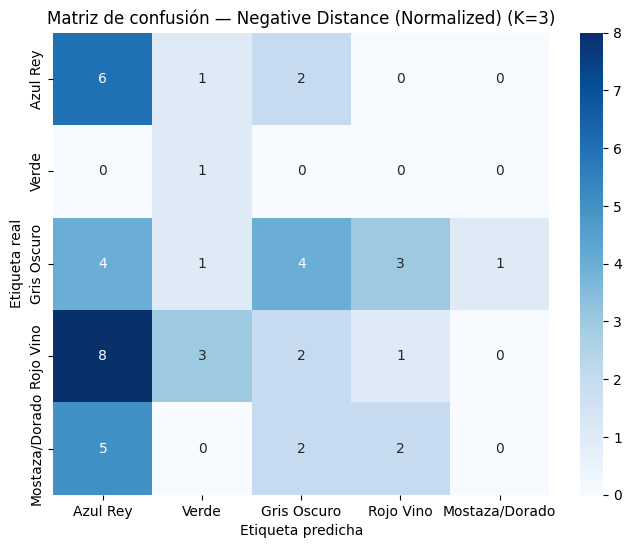


Primeras 5 probabilidades predichas del conjunto de prueba:
Real: #8B0000, Predicho: #0000CD, Probabilidades: {np.str_('#0000CD'): np.float64(0.33), np.str_('#008000'): np.float64(0.33), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.float64(0.33)}
Real: #008000, Predicho: #008000, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.33), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.float64(0.0)}
Real: #8B7500, Predicho: #0000CD, Probabilidades: {np.str_('#0000CD'): np.float64(0.33), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.float64(0.33)}
Real: #555555, Predicho: #0000CD, Probabilidades: {np.str_('#0000CD'): np.float64(1.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.

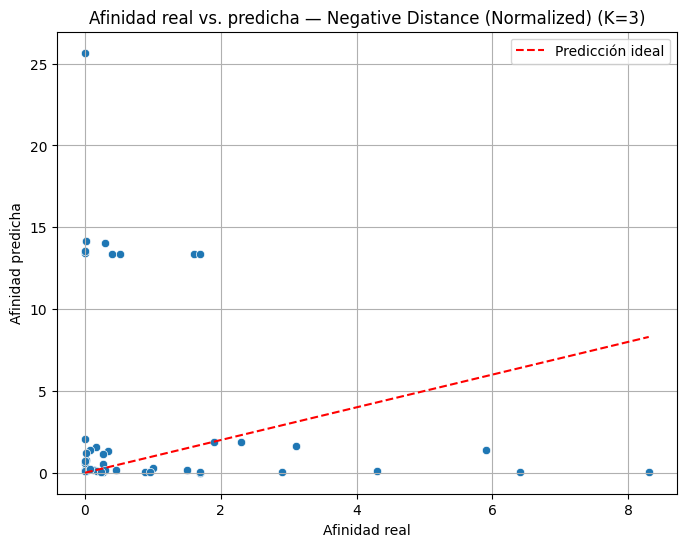


Primeros 5 valores reales vs. predichos:
Real: 0.0140, Predicho: 0.8024
Real: 0.0210, Predicho: 0.0768
Real: 0.0020, Predicho: 25.6693
Real: 0.3400, Predicho: 1.3565
Real: 0.2500, Predicho: 0.0260



Procesando: Positive Column Distance (Normalized)

--- Clasificación kNN (K=3) ---
Accuracy: 0.3043

Reporte de clasificación:
              precision    recall  f1-score   support

     #0000CD       0.20      0.11      0.14         9
     #008000       0.00      0.00      0.00         1
     #555555       0.22      0.31      0.26        13
     #8B0000       0.38      0.36      0.37        14
     #8B7500       0.50      0.44      0.47         9

    accuracy                           0.30        46
   macro avg       0.26      0.24      0.25        46
weighted avg       0.32      0.30      0.31        46


Matriz de confusión:


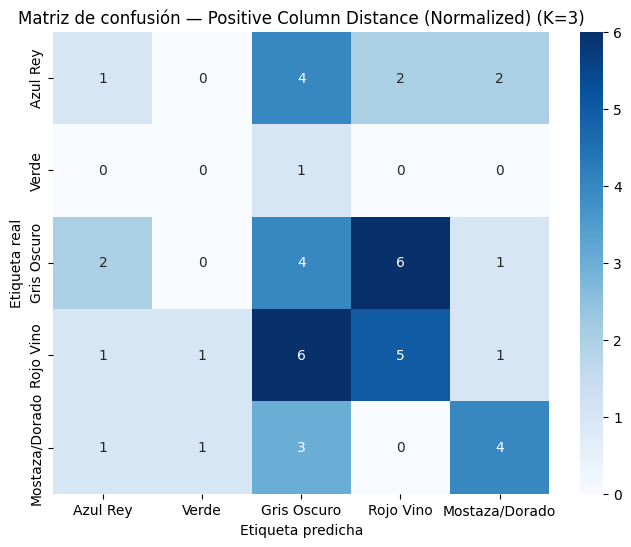


Primeras 5 probabilidades predichas del conjunto de prueba:
Real: #8B0000, Predicho: #8B0000, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.67), np.str_('#8B7500'): np.float64(0.33)}
Real: #008000, Predicho: #555555, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.67), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.float64(0.0)}
Real: #8B7500, Predicho: #8B7500, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.float64(0.67)}
Real: #555555, Predicho: #8B0000, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.67), np.str_('#8B7500'): np.fl

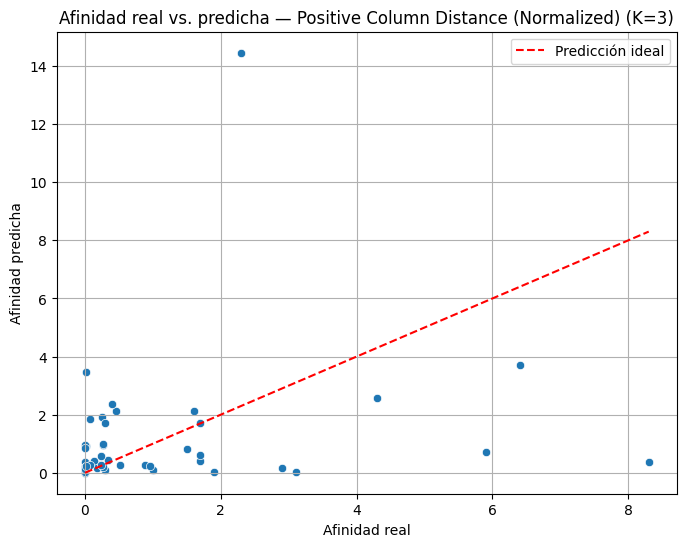


Primeros 5 valores reales vs. predichos:
Real: 0.0140, Predicho: 0.9067
Real: 0.0210, Predicho: 0.2997
Real: 0.0020, Predicho: 0.0088
Real: 0.3400, Predicho: 0.4330
Real: 0.2500, Predicho: 1.9123

Procesando: Mixed 50-50 Distance

--- Clasificación kNN (K=3) ---
Accuracy: 0.2826

Reporte de clasificación:
              precision    recall  f1-score   support

     #0000CD       0.21      0.33      0.26         9
     #008000       0.00      0.00      0.00         1
     #555555       0.24      0.38      0.29        13
     #8B0000       0.50      0.36      0.42        14
     #8B7500       0.00      0.00      0.00         9

    accuracy                           0.28        46
   macro avg       0.19      0.22      0.19        46
weighted avg       0.26      0.28      0.26        46


Matriz de confusión:


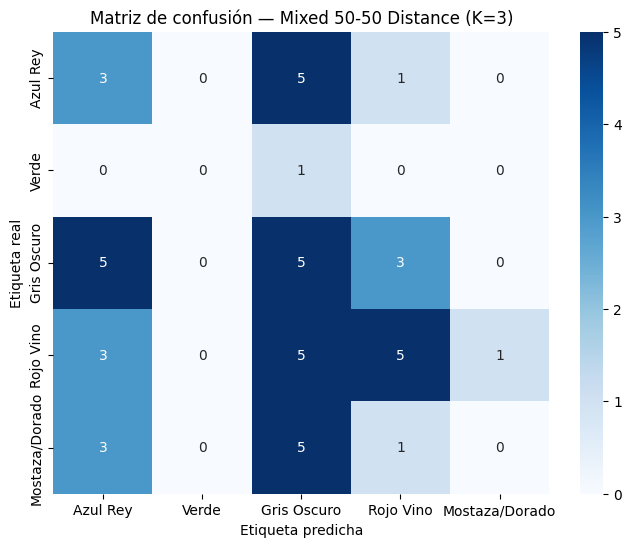


Primeras 5 probabilidades predichas del conjunto de prueba:
Real: #8B0000, Predicho: #8B7500, Probabilidades: {np.str_('#0000CD'): np.float64(0.33), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.float64(0.67)}
Real: #008000, Predicho: #555555, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.float64(0.33)}
Real: #8B7500, Predicho: #555555, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.float64(0.33)}
Real: #555555, Predicho: #0000CD, Probabilidades: {np.str_('#0000CD'): np.float64(1.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.f

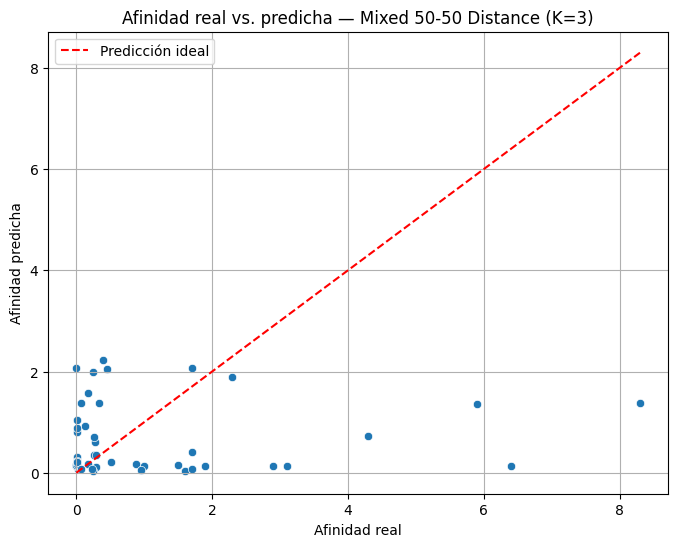


Primeros 5 valores reales vs. predichos:
Real: 0.0140, Predicho: 1.0467
Real: 0.0210, Predicho: 0.0721
Real: 0.0020, Predicho: 0.1330
Real: 0.3400, Predicho: 1.3863
Real: 0.2500, Predicho: 1.9835



Procesando: Mixed 30-70 Distance

--- Clasificación kNN (K=3) ---
Accuracy: 0.3696

Reporte de clasificación:
              precision    recall  f1-score   support

     #0000CD       0.18      0.22      0.20         9
     #008000       0.00      0.00      0.00         1
     #555555       0.27      0.31      0.29        13
     #8B0000       0.53      0.64      0.58        14
     #8B7500       0.67      0.22      0.33         9

    accuracy                           0.37        46
   macro avg       0.33      0.28      0.28        46
weighted avg       0.40      0.37      0.36        46


Matriz de confusión:


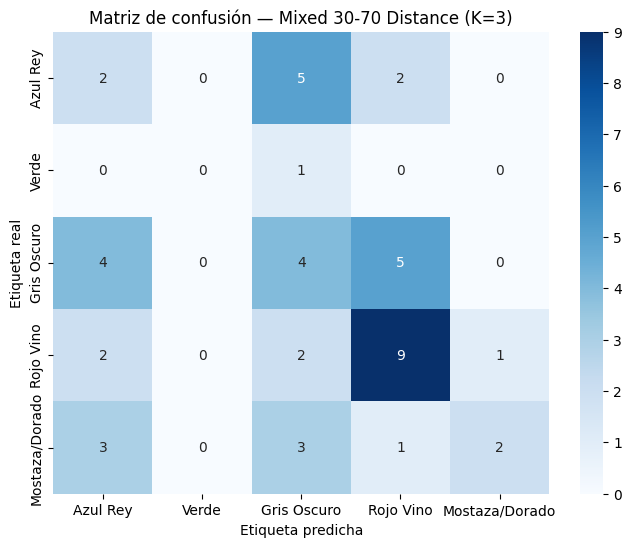


Primeras 5 probabilidades predichas del conjunto de prueba:
Real: #8B0000, Predicho: #8B0000, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.67), np.str_('#8B7500'): np.float64(0.33)}
Real: #008000, Predicho: #555555, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.67), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.float64(0.0)}
Real: #8B7500, Predicho: #0000CD, Probabilidades: {np.str_('#0000CD'): np.float64(0.33), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.float64(0.33)}
Real: #555555, Predicho: #0000CD, Probabilidades: {np.str_('#0000CD'): np.float64(0.33), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.

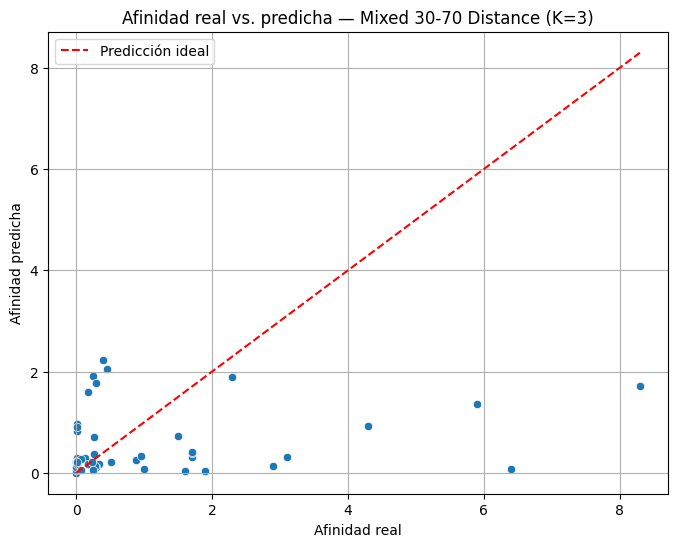


Primeros 5 valores reales vs. predichos:
Real: 0.0140, Predicho: 0.9667
Real: 0.0210, Predicho: 0.0554
Real: 0.0020, Predicho: 0.0062
Real: 0.3400, Predicho: 0.1697
Real: 0.2500, Predicho: 1.9123

Procesando: Mixed 70-30 Distance

--- Clasificación kNN (K=3) ---
Accuracy: 0.2391

Reporte de clasificación:
              precision    recall  f1-score   support

     #0000CD       0.22      0.44      0.30         9
     #008000       1.00      1.00      1.00         1
     #555555       0.22      0.31      0.26        13
     #8B0000       0.29      0.14      0.19        14
     #8B7500       0.00      0.00      0.00         9

    accuracy                           0.24        46
   macro avg       0.35      0.38      0.35        46
weighted avg       0.21      0.24      0.21        46


Matriz de confusión:


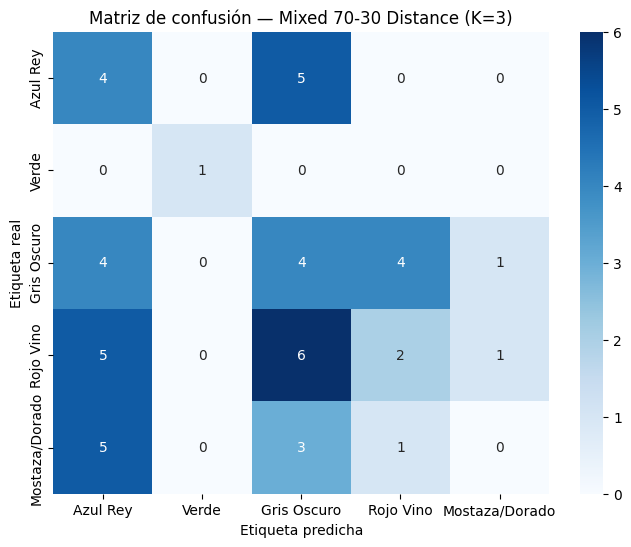


Primeras 5 probabilidades predichas del conjunto de prueba:
Real: #8B0000, Predicho: #8B7500, Probabilidades: {np.str_('#0000CD'): np.float64(0.33), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.float64(0.67)}
Real: #008000, Predicho: #008000, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.33), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.float64(0.0)}
Real: #8B7500, Predicho: #555555, Probabilidades: {np.str_('#0000CD'): np.float64(0.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.33), np.str_('#8B0000'): np.float64(0.33), np.str_('#8B7500'): np.float64(0.33)}
Real: #555555, Predicho: #0000CD, Probabilidades: {np.str_('#0000CD'): np.float64(1.0), np.str_('#008000'): np.float64(0.0), np.str_('#555555'): np.float64(0.0), np.str_('#8B0000'): np.float64(0.0), np.str_('#8B7500'): np.f

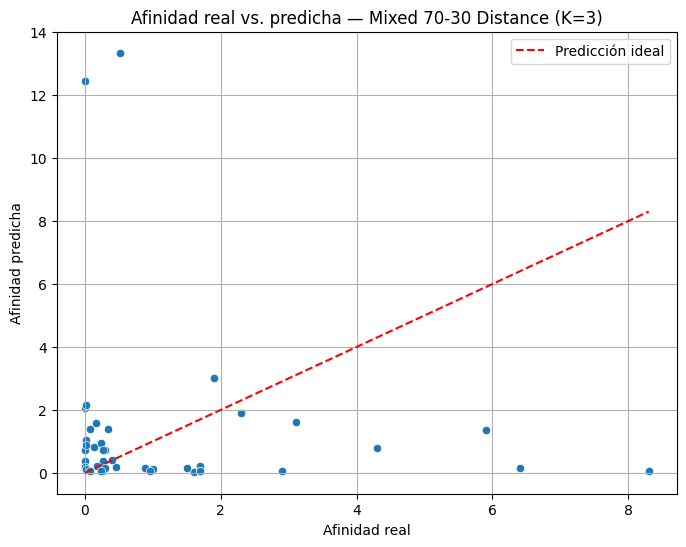


Primeros 5 valores reales vs. predichos:
Real: 0.0140, Predicho: 1.0467
Real: 0.0210, Predicho: 0.0768
Real: 0.0020, Predicho: 12.4610
Real: 0.3400, Predicho: 1.3993
Real: 0.2500, Predicho: 0.1033

Todos los modelos kNN de clasificación y regresión fueron procesados. Resultados almacenados en 'all_results'.


In [11]:
K_RANGE_FOR_CALCULATIONS = range(1, 21)   # Rango de vecinos a evaluar (método del codo)
K_FOR_DETAILED_REPORT = 3                 # K usado para el reporte detallado de clasificación
K_REGRESSION_FOR_DETAILED_REPORT = 3      # K usado para el reporte detallado de regresión

distance_matrices = {
    'Negative Distance (Normalized)': distance_neg_norm,
    'Positive Column Distance (Normalized)': distance_pos_col_norm,
    'Mixed 50-50 Distance': distance_mix_50_50_norm,
    'Mixed 30-70 Distance': distance_mix_30_70_norm,
    'Mixed 70-30 Distance': distance_mix_70_30_norm,
}

all_results = {}

for name, X_df_full in distance_matrices.items():
    print(f"\n{'='*50}\nProcesando: {name}\n{'='*50}")

    all_results[name] = {'accuracies': [], 'mses': [], 'r2_scores': []}

    # Sub-matriz de distancias restringida a las moléculas válidas (conocidas).
    X_df_filtered = X_df_full.loc[valid_mol_ids, valid_mol_ids]
    X_full_distance_matrix = X_df_filtered.values
    indices = np.arange(len(valid_mol_ids))

    # Corrección de eficiencia: el split train/test no depende de k_neighbors (mismo
    # random_state en cada iteración), así que se calcula UNA sola vez fuera del loop de k,
    # en lugar de recalcularlo idénticamente 20 veces como en la versión original.
    train_idx_c, test_idx_c, y_train_c, y_test_c = train_test_split(
        indices, y_class, test_size=0.3, random_state=42, stratify=y_class)
    train_idx_r, test_idx_r, y_train_r, y_test_r = train_test_split(
        indices, y_reg, test_size=0.3, random_state=42)

    X_train_c = X_full_distance_matrix[np.ix_(train_idx_c, train_idx_c)]
    X_test_c = X_full_distance_matrix[np.ix_(test_idx_c, train_idx_c)]
    X_train_r = X_full_distance_matrix[np.ix_(train_idx_r, train_idx_r)]
    X_test_r = X_full_distance_matrix[np.ix_(test_idx_r, train_idx_r)]

    for k_neighbors in K_RANGE_FOR_CALCULATIONS:
        # --- Clasificación ---
        knn_classifier = KNeighborsClassifier(n_neighbors=k_neighbors, metric='precomputed')
        knn_classifier.fit(X_train_c, y_train_c)
        y_pred_c = knn_classifier.predict(X_test_c)
        accuracy = accuracy_score(y_test_c, y_pred_c)
        all_results[name]['accuracies'].append(accuracy)

        # --- Regresión ---
        knn_regressor = KNeighborsRegressor(n_neighbors=k_neighbors, metric='precomputed')
        knn_regressor.fit(X_train_r, y_train_r)
        y_pred_r = knn_regressor.predict(X_test_r)
        mse = mean_squared_error(y_test_r, y_pred_r)
        r2 = r2_score(y_test_r, y_pred_r)
        all_results[name]['mses'].append(mse)
        all_results[name]['r2_scores'].append(r2)

        # Reporte y gráficas detalladas solo para el K de referencia (clasificación).
        if k_neighbors == K_FOR_DETAILED_REPORT:
            all_results[name]['classifier'] = knn_classifier
            print(f"\n--- Clasificación kNN (K={k_neighbors}) ---")
            print(f"Accuracy: {accuracy:.4f}")
            print("\nReporte de clasificación:")
            print(classification_report(y_test_c, y_pred_c, zero_division=0))
            print("\nMatriz de confusión:")
            cm = confusion_matrix(y_test_c, y_pred_c, labels=knn_classifier.classes_)
            plt.figure(figsize=(8, 6))
            class_names = [color_hex_to_name_map.get(h, h) for h in knn_classifier.classes_]
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=class_names, yticklabels=class_names)
            plt.title(f'Matriz de confusión — {name} (K={k_neighbors})')
            plt.xlabel('Etiqueta predicha')
            plt.ylabel('Etiqueta real')
            plt.show()
            print("\nPrimeras 5 probabilidades predichas del conjunto de prueba:")
            y_proba_c = knn_classifier.predict_proba(X_test_c)
            for i in range(min(5, len(y_test_c))):
                print(f"Real: {y_test_c[i]}, Predicho: {y_pred_c[i]}, "
                      f"Probabilidades: {dict(zip(knn_classifier.classes_, y_proba_c[i].round(2)))}")

        # Reporte y gráficas detalladas solo para el K de referencia (regresión).
        if k_neighbors == K_REGRESSION_FOR_DETAILED_REPORT:
            all_results[name]['regressor'] = knn_regressor
            print(f"\n--- Regresión kNN (K={k_neighbors}) ---")
            print(f"Error cuadrático medio (MSE): {mse:.4f}")
            print(f"R-cuadrado: {r2:.4f}")

            plt.figure(figsize=(8, 6))
            sns.scatterplot(x=y_test_r, y=y_pred_r)
            plt.title(f'Afinidad real vs. predicha — {name} (K={k_neighbors})')
            plt.xlabel('Afinidad real')
            plt.ylabel('Afinidad predicha')
            plt.grid(True)
            plt.plot([min(y_test_r), max(y_test_r)], [min(y_test_r), max(y_test_r)],
                     color='red', linestyle='--', label='Predicción ideal')
            plt.legend()
            plt.show()

            print("\nPrimeros 5 valores reales vs. predichos:")
            for i in range(min(5, len(y_test_r))):
                print(f"Real: {y_test_r[i]:.4f}, Predicho: {y_pred_r[i]:.4f}")

print("\nTodos los modelos kNN de clasificación y regresión fueron procesados. "
      "Resultados almacenados en 'all_results'.")

## 7. Predicción para las 20 moléculas de pose sin afinidad conocida

Con la corrección de identificadores únicos (§5), aquí ya no hace falta el parche que el
cuaderno original necesitaba para "adivinar" nombres de display cuando todo colapsaba a
`"xyz"`: cada molécula de pose (`xyz_newmol0`, ..., `xyz_newmol19`) se referencia directamente
por su propio ID único con `.loc[...]`.

In [12]:
# Las moléculas de pose son las que están en las matrices pero no en valid_mol_ids.
unknown_mol_ids = [m for m in mol_ids_from_matrix_cleaned if m not in valid_mol_ids]
print(f"Identificadas {len(unknown_mol_ids)} moléculas sin afinidad conocida: {unknown_mol_ids}\n")

for name, results in all_results.items():
    if 'classifier' not in results:
        print(f"No se encontró clasificador para {name} en K={K_FOR_DETAILED_REPORT}.")
        continue

    knn_classifier = results['classifier']
    X_df_full = distance_matrices[name]

    # Se reconstruyen los IDs de entrenamiento usados en la clasificación (mismo split,
    # mismo random_state, así que el resultado es idéntico al usado al entrenar).
    indices_all_valid = np.arange(len(valid_mol_ids))
    train_indices_c, _, _, _ = train_test_split(
        indices_all_valid, y_class, test_size=0.3, random_state=42, stratify=y_class)
    training_mol_ids = np.array(valid_mol_ids)[train_indices_c]

    # Distancias de cada molécula desconocida hacia el conjunto de entrenamiento.
    X_unknown_to_train = X_df_full.loc[unknown_mol_ids, training_mol_ids].values
    probabilities = knn_classifier.predict_proba(X_unknown_to_train)

    unknown_mol_probs_list = []
    for i, mol_id in enumerate(unknown_mol_ids):
        fila = {'Molécula': mol_id}
        for j, class_label in enumerate(knn_classifier.classes_):
            class_name = color_hex_to_name_map.get(class_label, class_label)
            fila[class_name] = round(probabilities[i, j], 4)
        unknown_mol_probs_list.append(fila)
    all_results[name]['unknown_probabilities'] = unknown_mol_probs_list

Identificadas 20 moléculas sin afinidad conocida: ['xyz_newmol0_neg', 'xyz_newmol10_neg', 'xyz_newmol11_neg', 'xyz_newmol12_neg', 'xyz_newmol13_neg', 'xyz_newmol14_neg', 'xyz_newmol15_neg', 'xyz_newmol16_neg', 'xyz_newmol17_neg', 'xyz_newmol18_neg', 'xyz_newmol19_neg', 'xyz_newmol1_neg', 'xyz_newmol2_neg', 'xyz_newmol3_neg', 'xyz_newmol4_neg', 'xyz_newmol5_neg', 'xyz_newmol6_neg', 'xyz_newmol7_neg', 'xyz_newmol8_neg', 'xyz_newmol9_neg']



In [13]:
from IPython.display import display

print("\n--- Tablas de probabilidades para moléculas desconocidas ---\n")

for name, results in all_results.items():
    if 'unknown_probabilities' not in results:
        print(f"No se encontraron probabilidades para moléculas desconocidas en {name}.")
        continue
    print(f"\nProbabilidades para {name} (K={K_FOR_DETAILED_REPORT}):")
    df_probabilities = pd.DataFrame(results['unknown_probabilities'])
    cols = ['Molécula'] + sorted(c for c in df_probabilities.columns if c != 'Molécula')
    display(df_probabilities[cols])


--- Tablas de probabilidades para moléculas desconocidas ---


Probabilidades para Negative Distance (Normalized) (K=3):


,Molécula,Azul Rey,Gris Oscuro,Mostaza/Dorado,Rojo Vino,Verde
0,xyz_newmol0_neg,0.0000,0.0000,0.3333,0.6667,0.0000
1,xyz_newmol10_neg,0.3333,0.3333,0.0000,0.3333,0.0000
2,xyz_newmol11_neg,0.3333,0.0000,0.0000,0.6667,0.0000
3,xyz_newmol12_neg,0.0000,0.0000,1.0000,0.0000,0.0000
4,xyz_newmol13_neg,0.3333,0.0000,0.6667,0.0000,0.0000
5,xyz_newmol14_neg,0.3333,0.0000,0.0000,0.6667,0.0000
6,xyz_newmol15_neg,0.0000,0.6667,0.0000,0.3333,0.0000
7,xyz_newmol16_neg,0.3333,0.0000,0.0000,0.3333,0.3333
8,xyz_newmol17_neg,0.6667,0.0000,0.0000,0.3333,0.0000
9,xyz_newmol18_neg,0.0000,0.0000,0.3333,0.6667,0.0000



Probabilidades para Positive Column Distance (Normalized) (K=3):


,Molécula,Azul Rey,Gris Oscuro,Mostaza/Dorado,Rojo Vino,Verde
0,xyz_newmol0_neg,0.0000,0.6667,0.0000,0.3333,0.0000
1,xyz_newmol10_neg,0.0000,0.0000,0.0000,1.0000,0.0000
2,xyz_newmol11_neg,0.0000,0.3333,0.0000,0.6667,0.0000
3,xyz_newmol12_neg,0.0000,0.0000,0.6667,0.3333,0.0000
4,xyz_newmol13_neg,0.0000,1.0000,0.0000,0.0000,0.0000
5,xyz_newmol14_neg,0.0000,0.3333,0.3333,0.3333,0.0000
6,xyz_newmol15_neg,0.0000,0.3333,0.3333,0.3333,0.0000
7,xyz_newmol16_neg,0.0000,0.0000,0.3333,0.0000,0.6667
8,xyz_newmol17_neg,0.0000,0.0000,0.3333,0.0000,0.6667
9,xyz_newmol18_neg,0.0000,0.3333,0.3333,0.3333,0.0000



Probabilidades para Mixed 50-50 Distance (K=3):


,Molécula,Azul Rey,Gris Oscuro,Mostaza/Dorado,Rojo Vino,Verde
0,xyz_newmol0_neg,0.0000,0.3333,0.3333,0.3333,0.0000
1,xyz_newmol10_neg,0.0000,0.3333,0.0000,0.6667,0.0000
2,xyz_newmol11_neg,0.0000,0.3333,0.3333,0.3333,0.0000
3,xyz_newmol12_neg,0.0000,0.0000,1.0000,0.0000,0.0000
4,xyz_newmol13_neg,0.3333,0.0000,0.6667,0.0000,0.0000
5,xyz_newmol14_neg,0.0000,0.0000,0.6667,0.3333,0.0000
6,xyz_newmol15_neg,0.0000,0.6667,0.0000,0.3333,0.0000
7,xyz_newmol16_neg,0.0000,0.3333,0.3333,0.0000,0.3333
8,xyz_newmol17_neg,0.3333,0.0000,0.3333,0.3333,0.0000
9,xyz_newmol18_neg,0.0000,0.0000,0.0000,1.0000,0.0000



Probabilidades para Mixed 30-70 Distance (K=3):


,Molécula,Azul Rey,Gris Oscuro,Mostaza/Dorado,Rojo Vino,Verde
0,xyz_newmol0_neg,0.0000,0.3333,0.0000,0.6667,0.0000
1,xyz_newmol10_neg,0.0000,0.3333,0.0000,0.6667,0.0000
2,xyz_newmol11_neg,0.0000,0.3333,0.3333,0.3333,0.0000
3,xyz_newmol12_neg,0.0000,0.0000,0.6667,0.3333,0.0000
4,xyz_newmol13_neg,0.0000,0.3333,0.6667,0.0000,0.0000
5,xyz_newmol14_neg,0.0000,0.0000,0.6667,0.3333,0.0000
6,xyz_newmol15_neg,0.0000,0.6667,0.0000,0.3333,0.0000
7,xyz_newmol16_neg,0.0000,0.0000,0.3333,0.0000,0.6667
8,xyz_newmol17_neg,0.0000,0.0000,0.3333,0.3333,0.3333
9,xyz_newmol18_neg,0.0000,0.0000,0.3333,0.6667,0.0000



Probabilidades para Mixed 70-30 Distance (K=3):


,Molécula,Azul Rey,Gris Oscuro,Mostaza/Dorado,Rojo Vino,Verde
0,xyz_newmol0_neg,0.0000,0.0000,0.3333,0.6667,0.0000
1,xyz_newmol10_neg,0.3333,0.3333,0.0000,0.3333,0.0000
2,xyz_newmol11_neg,0.0000,0.3333,0.3333,0.3333,0.0000
3,xyz_newmol12_neg,0.0000,0.0000,1.0000,0.0000,0.0000
4,xyz_newmol13_neg,0.3333,0.0000,0.6667,0.0000,0.0000
5,xyz_newmol14_neg,0.3333,0.0000,0.3333,0.3333,0.0000
6,xyz_newmol15_neg,0.0000,1.0000,0.0000,0.0000,0.0000
7,xyz_newmol16_neg,0.0000,0.3333,0.0000,0.3333,0.3333
8,xyz_newmol17_neg,0.3333,0.0000,0.0000,0.6667,0.0000
9,xyz_newmol18_neg,0.0000,0.0000,0.0000,1.0000,0.0000


## 8. Método del codo (elbow method) para elegir K

**Corrección:** el cuaderno original repetía esta celda dos veces de forma idéntica; aquí
queda una sola vez.


--- Generando gráficas del método del codo ---



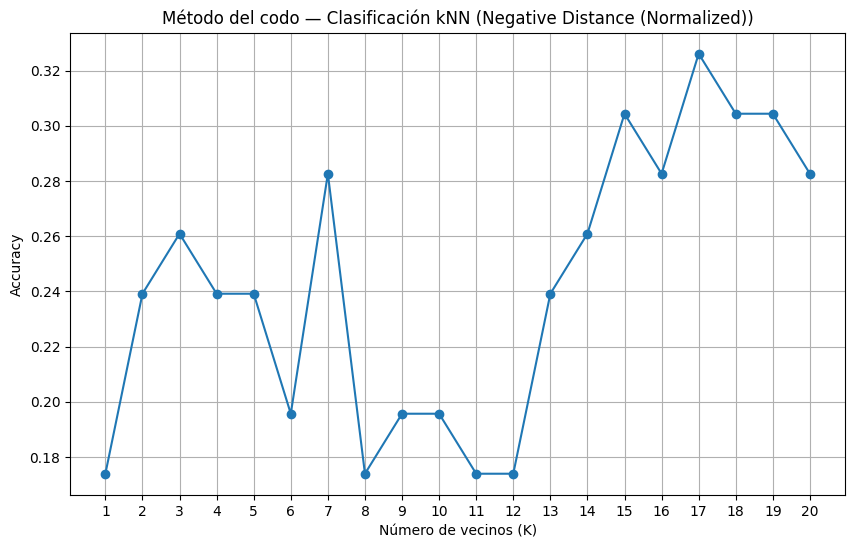

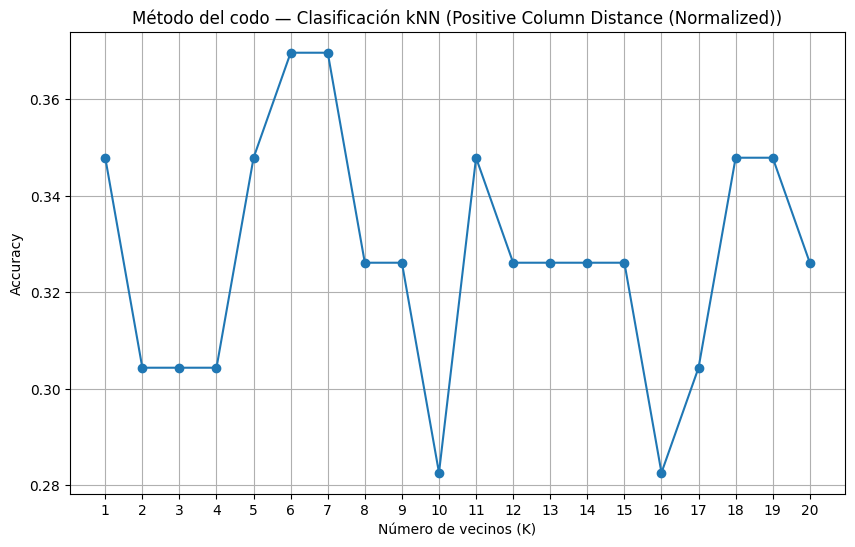

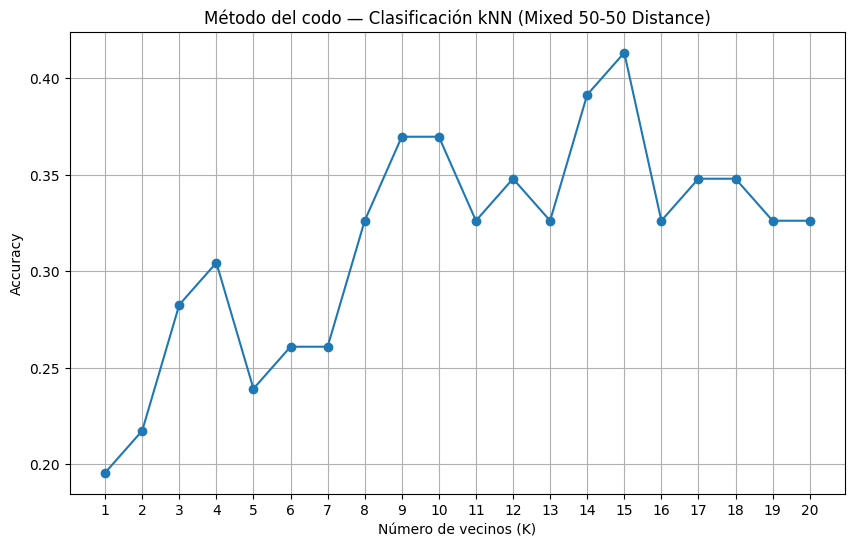

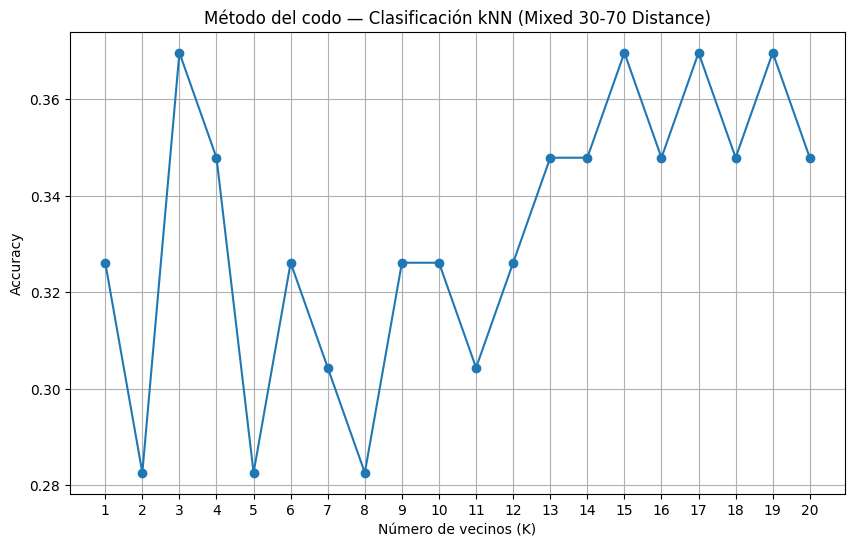

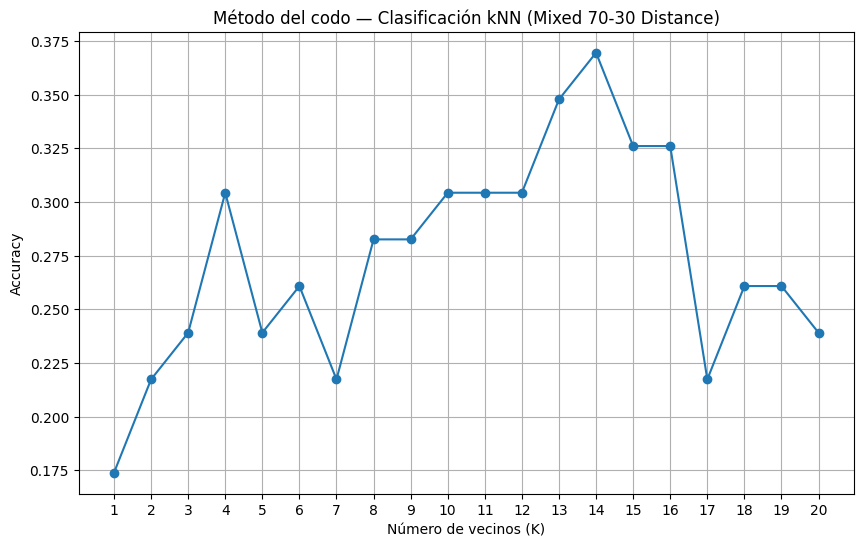


Todas las gráficas del método del codo fueron generadas.


In [14]:
k_range_for_plotting = range(1, 21)

print("\n--- Generando gráficas del método del codo ---\n")
for name, results in all_results.items():
    accuracies = results['accuracies']
    plt.figure(figsize=(10, 6))
    plt.plot(k_range_for_plotting, accuracies[:len(k_range_for_plotting)], marker='o')
    plt.title(f'Método del codo — Clasificación kNN ({name})')
    plt.xlabel('Número de vecinos (K)')
    plt.ylabel('Accuracy')
    plt.xticks(k_range_for_plotting)
    plt.grid(True)
    plt.show()

print("\nTodas las gráficas del método del codo fueron generadas.")

## 9. Dendrogramas coloreados (patrones entre moléculas)

Sección añadida para efectivamente usar las funciones de coloreado definidas en §3, que en
el cuaderno original quedaban sin invocar. Se construye un dendrograma por cada matriz de
distancia (clustering jerárquico aglomerativo, enlace promedio) coloreado según la categoría
de afinidad de cada molécula conocida, para identificar visualmente patrones/agrupaciones.

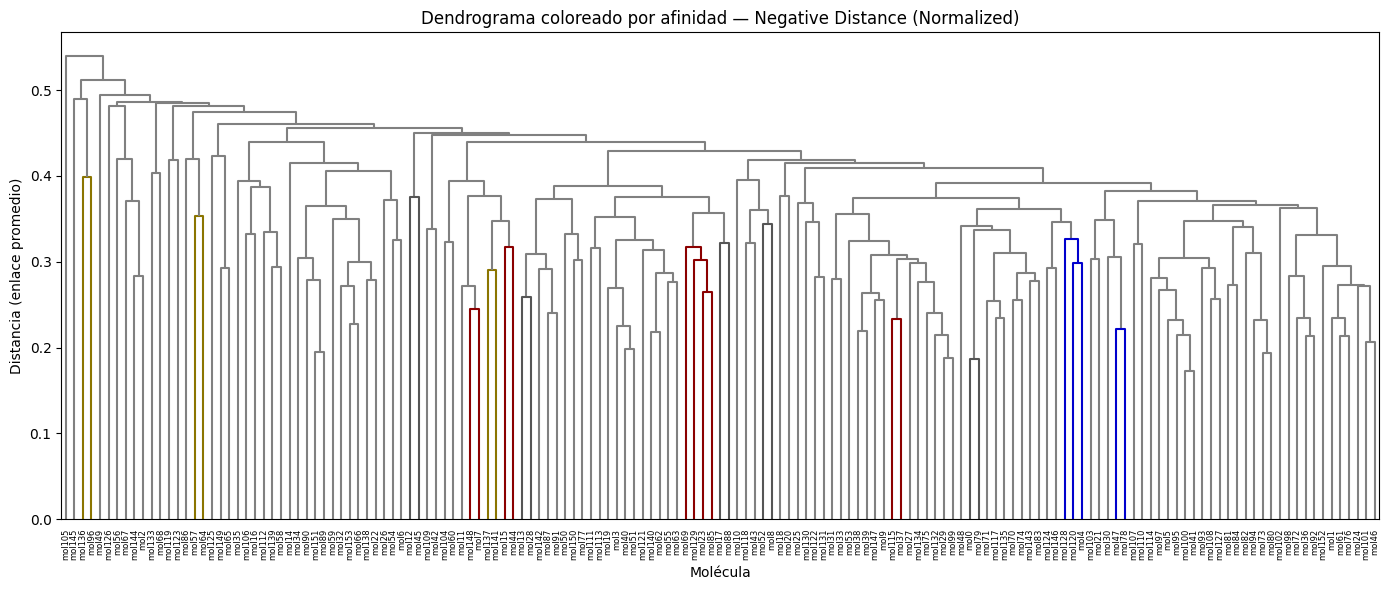

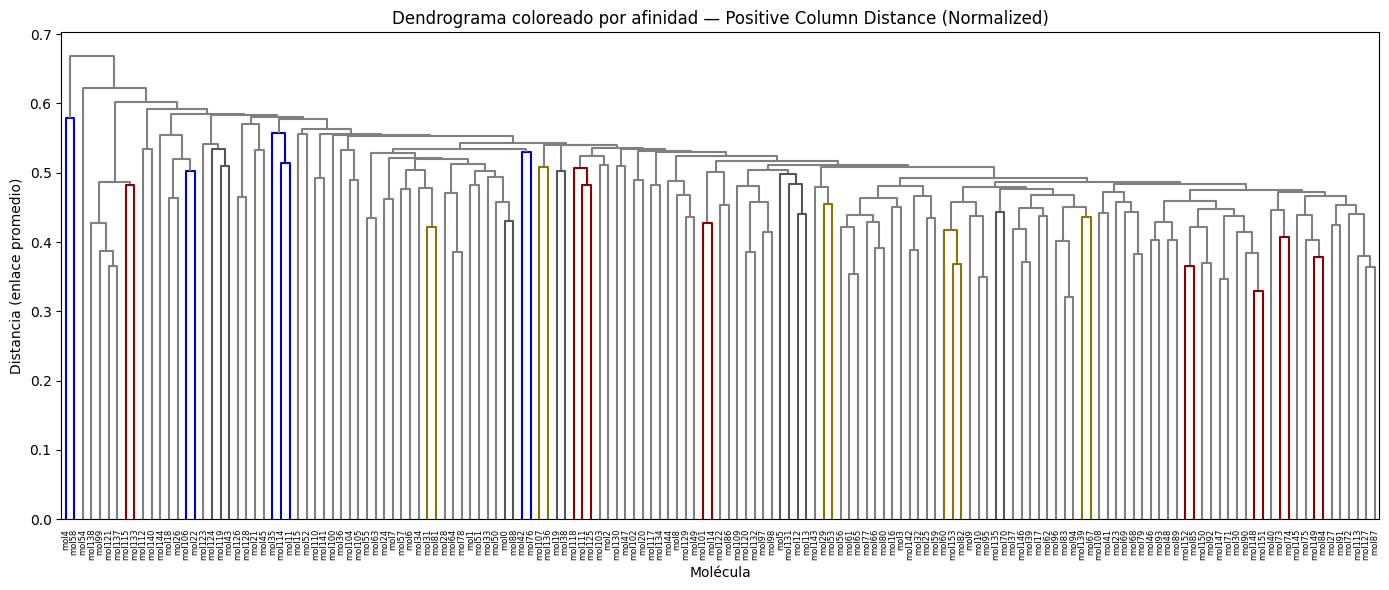

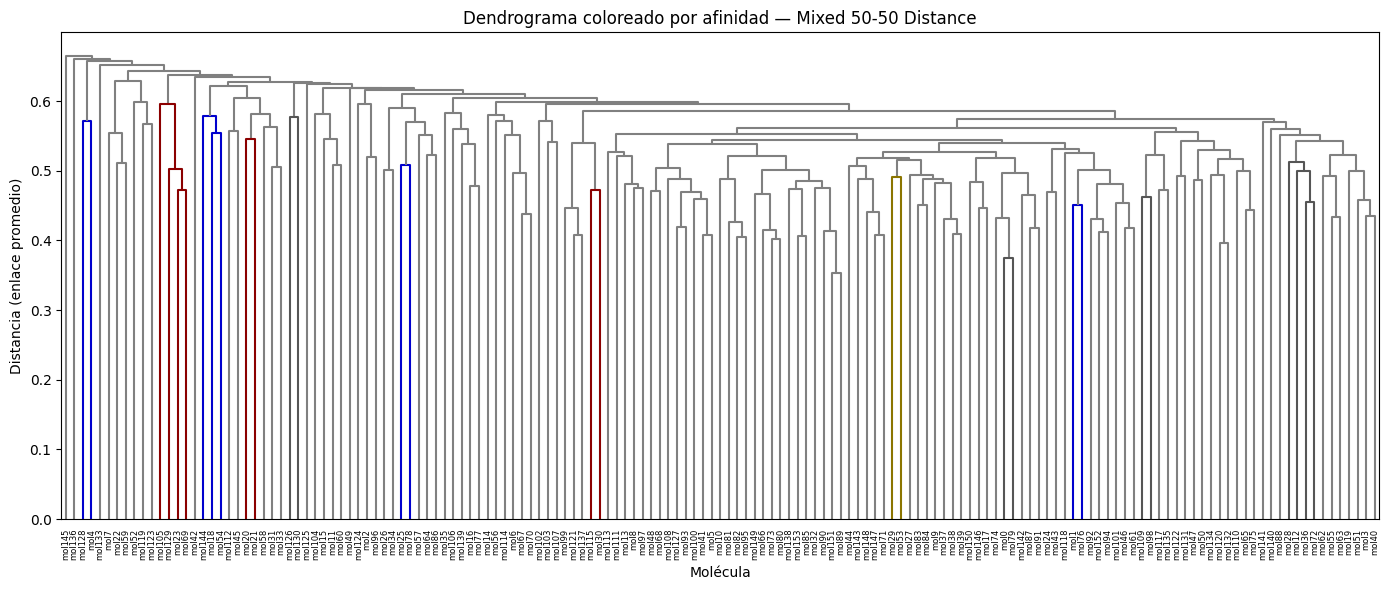

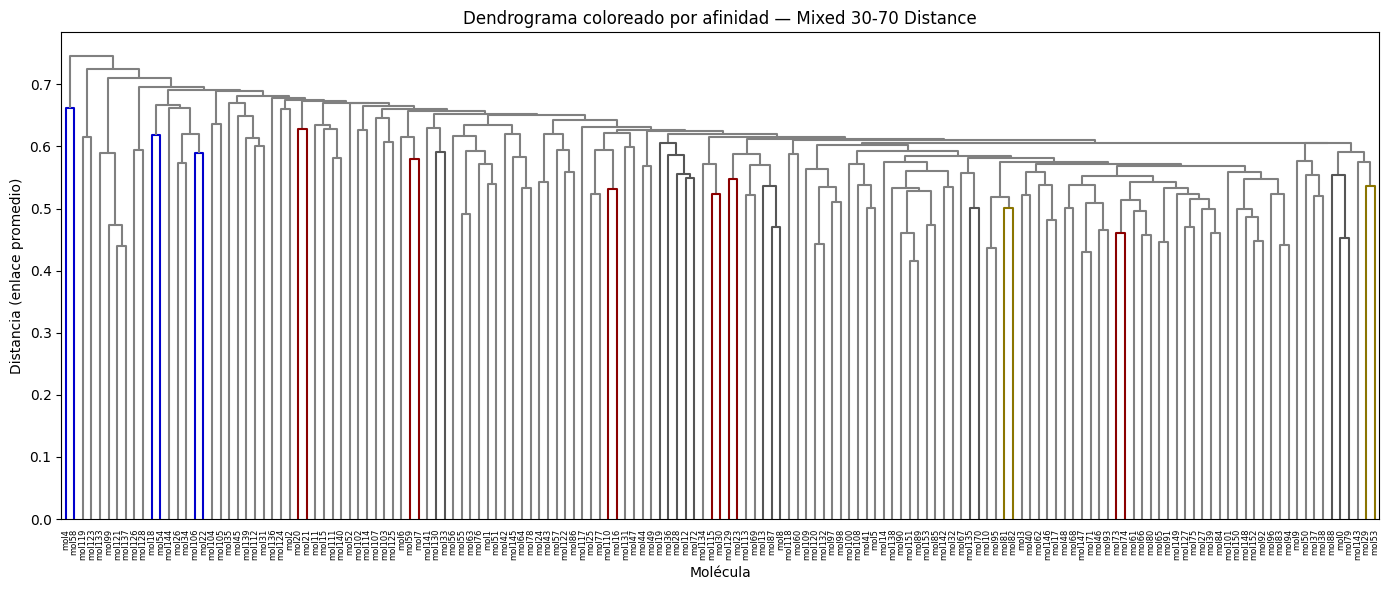

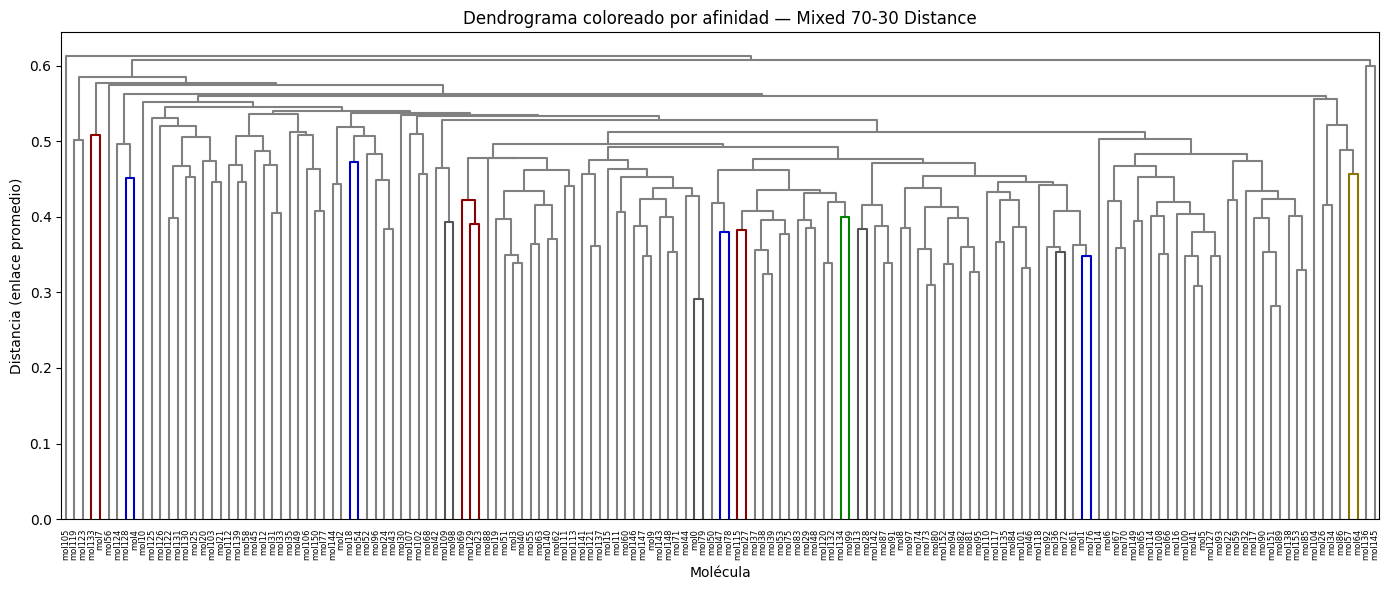

In [15]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

for name, X_df_full in distance_matrices.items():
    X_df_filtered = X_df_full.loc[valid_mol_ids, valid_mol_ids]
    # squareform requiere una matriz de distancias simétrica con diagonal en cero.
    matriz_condensada = squareform(X_df_filtered.values, checks=False)
    Z = linkage(matriz_condensada, method='average')

    plt.figure(figsize=(14, 6))
    dendrogram(
        Z,
        labels=valid_mol_ids,
        link_color_func=lambda k: custom_link_color_func(
            k, Z, valid_mol_ids, color_map, clean_mol_id),
        leaf_rotation=90,
        leaf_font_size=6,
    )
    plt.title(f'Dendrograma coloreado por afinidad — {name}')
    plt.xlabel('Molécula')
    plt.ylabel('Distancia (enlace promedio)')
    plt.tight_layout()
    plt.show()